# Challenge 03 — Analítica Multidimensional
### TechLogistics S.A. · Metodología CRISP-DM · EAFIT — Maestría en Ciencia de los Datos

> **Nota sobre la numeración.** El PDF entregado por el docente se titula "Challenge 02",
> pero corresponde al **workshop de la Lecture 03**; unificamos la etiqueta a **Challenge 03**
> (el "02" fue un error de numeración en el documento fuente).

Este notebook resuelve, de principio a fin, el reto de **analítica multidimensional**
sobre dos dominios operativos de TechLogistics:

- **Agroindustria / Clima** (`agro_*`) — red de sensores tipo *mesh* en el Oriente Antioqueño.
- **Energía / Economía** (`ener_*`) — red de *despacho* eléctrico.

Se cubren cuatro fases CRISP-DM: (1) *Data Understanding* + geo-visualización,
(2) procesamiento de señales y filtrado, (3) grafos y topología de red, y
(4) modelado y decisiones de negocio.

---
## Supuestos metodológicos (declarados explícitamente)

1. **Existencia de señal *clean*.** El brief asumía que *solo* se entregaron los archivos
   `*_noise`. Sin embargo, los archivos `agro_clean.csv` y `ener_clean.csv` **sí existen**
   en `data/`. Por rigor usamos esa **señal limpia real como referencia (ground truth)**
   para SNR y RMSE, en lugar de estimarla. Aun así construimos la versión *denoised*
   (Butterworth / media móvil) para demostrar el pipeline de filtrado y para el caso en
   que la referencia no estuviera disponible.
2. **Sin timestamp.** Los CSV no traen columna temporal. Creamos un `DatetimeIndex`
   **sintético horario** (`freq='h'`, inicio fijo `2023-01-01`) para todo el análisis de
   series de tiempo. Es un supuesto: asume muestreo equiespaciado de 1 registro/hora.
3. **Reproducibilidad.** Fijamos la semilla de NumPy (`seed=42`).
4. **Diccionario de variables.** Interpretamos cada variable según el diccionario provisto
   (no se inventan significados).

### Bootstrap (Google Colab / entornos sin el repo clonado)

Este notebook importa código desde el paquete local `src/` y lee los CSV de `data/`. En **Google Colab** (o cualquier máquina sin el repositorio) esos archivos no existen y `from src import ...` fallaría. La siguiente celda lo resuelve automáticamente: si no encuentra el proyecto, **clona el repositorio de GitHub**, entra en él e instala las dependencias que Colab no trae (p. ej. `pmdarima`). En ejecución local no hace nada.

In [6]:
# --- Bootstrap portátil: hace que el notebook corra igual en local y en Colab ---
import os, sys, subprocess
from pathlib import Path

REPO_URL = "https://github.com/santiagovelcasallas/Challenge03_techlogistics-GomezVelez.git"
REPO_DIR = "Challenge03_techlogistics-GomezVelez"

def _project_here(p) -> bool:
    p = Path(p)
    return (p / "src").is_dir() and (p / "data").is_dir()

# ¿El proyecto ya está disponible (ejecución local dentro del repo)?
_found = any(_project_here(p) for p in [Path.cwd(), *Path.cwd().parents])

if not _found:
    print("Proyecto no encontrado localmente -> preparando repo desde GitHub (modo Colab)...")
    if not Path(REPO_DIR).is_dir():
        subprocess.run(["git", "clone", "--depth", "1", REPO_URL], check=True)
    else:
        # El clon ya existe (corrida previa): traer lo ULTIMO para no usar copia vieja.
        subprocess.run(["git", "-C", REPO_DIR, "fetch", "--depth", "1", "origin", "main"], check=False)
        subprocess.run(["git", "-C", REPO_DIR, "reset", "--hard", "FETCH_HEAD"], check=False)
    os.chdir(REPO_DIR)
    # Dependencias que Colab no incluye por defecto (best-effort: el modelo P3
    # tiene fallback si pmdarima no queda disponible).
    subprocess.run([sys.executable, "-m", "pip", "install", "-q", "pmdarima", "contextily"], check=False)
    print("Repositorio listo. Directorio de trabajo:", Path.cwd())
else:
    print("Proyecto encontrado localmente. Directorio de trabajo:", Path.cwd())

Proyecto encontrado localmente. Directorio de trabajo: /content/Challenge03_techlogistics-GomezVelez


### Configuración del entorno y utilidades reutilizables (`src/`)

In [7]:
import sys
from pathlib import Path

# --- Localizar la raíz del proyecto de forma robusta (busca requirements.txt) ---
def find_root(start: Path) -> Path:
    p = start.resolve()
    for cand in [p, *p.parents]:
        if (cand / "requirements.txt").exists() and (cand / "src").exists():
            return cand
    return start.resolve().parent

ROOT = find_root(Path.cwd())
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

DATA = ROOT / "data"
FIGS = ROOT / "figures"
FIGS.mkdir(exist_ok=True)
print("Project root:", ROOT)

Project root: /content/Challenge03_techlogistics-GomezVelez


Importamos el stack científico y los módulos reutilizables de `src/`, y fijamos la semilla.

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from src import io_utils, stationarity, signal_utils, graph_utils, viz_utils

io_utils.set_seeds(42)               # reproducibilidad
sns.set_theme(style="whitegrid")
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")
print("Librerías cargadas correctamente.")

Librerías cargadas correctamente.


### Carga de datos y creación del índice temporal sintético

Cargamos los cuatro archivos y adjuntamos el índice horario sintético. Recordar que
`clean` es la **referencia real** y `noise` es la señal observada con ruido inyectado
(SNR objetivo del reto en el rango 5–12 dB).

In [9]:
agro_clean, agro_noise = io_utils.load_pair(DATA, "agro")
ener_clean, ener_noise = io_utils.load_pair(DATA, "ener")

AGRO_COLS = io_utils.value_columns(agro_noise, "Agro")
ENER_COLS = io_utils.value_columns(ener_noise, "Ener")

print("agro_noise:", agro_noise.shape, "| ener_noise:", ener_noise.shape)
print("Índice temporal sintético:", agro_noise.index.min(), "->", agro_noise.index.max())
agro_noise.head(3)

agro_noise: (2000, 14) | ener_noise: (2000, 14)
Índice temporal sintético: 2023-01-01 00:00:00 -> 2023-03-25 07:00:00


,Agro_1,Agro_2,Agro_3,Agro_4,Agro_5,Agro_6,Agro_7,Agro_8,Agro_9,Agro_10,Latitude,Longitude,Source_Node,Target_Node
timestamp,,,,,,,,,,,,,,
2023-01-01 00:00:00,59.0838,52.1888,64.1778,11.6235,0.5595,2.3782,5.7842,6.4689,1.2317,5.0869,6.2117,-75.4004,4,17
2023-01-01 01:00:00,56.1357,46.4884,67.3549,73.9948,0.5990,2.4066,5.4366,6.5148,1.0968,3.7416,6.2748,-75.4745,14,21
2023-01-01 02:00:00,61.0925,46.3521,73.2208,-17.8154,0.4283,2.3803,12.6869,6.4581,1.1768,7.6270,6.1593,-75.4769,14,22


Resumen estadístico rápido para entender escalas y detectar anomalías obvias.

In [10]:
display(agro_noise[AGRO_COLS].describe().T[["mean", "std", "min", "max"]])
display(ener_noise[ENER_COLS].describe().T[["mean", "std", "min", "max"]])

,mean,std,min,max
Agro_1,60.5025,10.8534,36.7468,81.6082
Agro_2,48.2174,9.4687,26.1418,71.1322
Agro_3,66.4935,11.9685,40.1657,91.3462
Agro_4,161.8385,206.2608,-227.5584,681.1405
Agro_5,1.1599,0.4091,0.1431,2.4317
Agro_6,2.9675,0.6261,1.1125,4.6703
Agro_7,20.9219,9.1294,-1.9052,48.9824
Agro_8,6.4979,0.1046,6.1359,6.9001
Agro_9,1.2022,0.0529,1.0389,1.3811
Agro_10,5.0226,1.5867,-0.5934,11.0914


,mean,std,min,max
Ener_1,99.2315,15.6988,62.3876,136.3217
Ener_2,148.6799,23.0406,95.2050,201.9384
Ener_3,24.7353,3.9308,14.3260,35.7123
Ener_4,39.5947,15.2392,-4.5410,81.1516
Ener_5,15.6138,6.6600,0.7555,28.8539
Ener_6,903.8400,59.4831,768.0042,"1,053.6978"
Ener_7,519.9399,12.2698,491.9267,548.3052
Ener_8,59.9996,0.0208,59.9314,60.0884
Ener_9,110.0171,0.5215,108.4570,112.1147
Ener_10,0.9501,0.0114,0.9063,0.9880


---
# FASE 1 — Data Understanding y Geo-Visualización

## T1 · Geo-visualización de sensores (Plotly `scatter_mapbox`)

Ubicamos los sensores agro en el mapa del Oriente Antioqueño. **Color = NDVI (`Agro_5`)**
(verde = vegetación sana, rojo = baja) y **tamaño = Humedad del suelo (`Agro_1`)**.
Buscamos *clustering espacial*: zonas donde la biomasa/NDVI es consistentemente baja,
candidatas a intervención. Usamos el estilo `open-street-map` (no requiere token Mapbox).

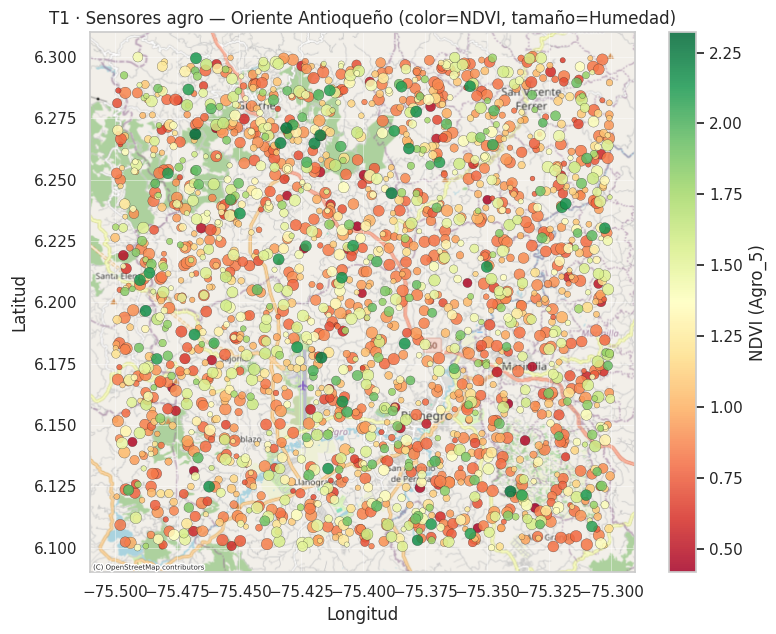

In [11]:
# Figura interactiva Plotly (mapa real OpenStreetMap) para exploración en el notebook
fig_geo = viz_utils.geo_sensor_map(
    agro_clean, color="Agro_5", size="Agro_1",
    color_label="NDVI (Agro_5)", size_label="Humedad (Agro_1)",
    title="T1 · Sensores agro — NDVI (color) y Humedad (tamaño)",
)

# PNG de evidencia con matplotlib (export estático fiable, sin dependencia de kaleido,
# que en Windows puede bloquear el kernel). Tamaño del marcador = Humedad normalizada.
import contextily as cx
_sz = 12 + 60 * (agro_clean["Agro_1"] - agro_clean["Agro_1"].min()) / \
      (agro_clean["Agro_1"].max() - agro_clean["Agro_1"].min())
fig, ax = plt.subplots(figsize=(8, 6.5))
sc = ax.scatter(agro_clean["Longitude"], agro_clean["Latitude"],
                c=agro_clean["Agro_5"], s=_sz, cmap="RdYlGn",
                alpha=0.85, edgecolor="k", linewidth=0.2, zorder=3)
# Capa de fondo: mapa real del Oriente Antioqueño (teselas OpenStreetMap, sin token),
# reproyectadas para alinearse a los ejes en coordenadas lat/lon (EPSG:4326).
cx.add_basemap(ax, crs="EPSG:4326", source=cx.providers.OpenStreetMap.Mapnik,
               attribution_size=5)
ax.set_xlabel("Longitud"); ax.set_ylabel("Latitud")
ax.set_title("T1 · Sensores agro — Oriente Antioqueño (color=NDVI, tamaño=Humedad)")
ax.grid(True, color="white", alpha=0.5, linewidth=0.6, zorder=2)  # grid lat/lon visible
plt.colorbar(sc, label="NDVI (Agro_5)")
fig.tight_layout(); viz_utils.savefig(FIGS / "t1_geo_ndvi.png"); plt.show()

fig_geo.show()  # versión interactiva (Plotly scatter_mapbox)

**Detección de clustering espacial de bajo NDVI.** Marcamos el cuartil inferior de NDVI
y verificamos si esos sensores se concentran geográficamente (usamos la mediana de
lat/lon como partición simple y reportamos la fracción de sensores de bajo NDVI por zona).

In [12]:
q1_ndvi = agro_clean["Agro_5"].quantile(0.25)
low = agro_clean[agro_clean["Agro_5"] <= q1_ndvi]
lat_med, lon_med = agro_clean["Latitude"].median(), agro_clean["Longitude"].median()

def zone(row):
    ns = "N" if row["Latitude"] >= lat_med else "S"
    ew = "E" if row["Longitude"] >= lon_med else "O"
    return ns + ew

agro_clean["_zona"] = agro_clean.apply(zone, axis=1)
low = low.assign(_zona=low.apply(zone, axis=1))
share = (low["_zona"].value_counts(normalize=True) * 100).round(1)
print(f"Umbral NDVI (Q1) = {q1_ndvi:.3f}. Distribución de sensores de BAJO NDVI por zona (%):")
print(share.to_string())
print("\\nComo el reparto ronda el 25% en cada cuadrante, a esta escala NO hay "
      "concentración por zona (lo confirmamos abajo, de forma rigurosa, con la I de Moran).")

Umbral NDVI (Q1) = 0.857. Distribución de sensores de BAJO NDVI por zona (%):
_zona
SE   26.0000
NE   25.4000
SO   25.0000
NO   23.6000
\nComo el reparto ronda el 25% en cada cuadrante, a esta escala NO hay concentración por zona (lo confirmamos abajo, de forma rigurosa, con la I de Moran).


### La forma rigurosa: **I de Moran** (autocorrelación espacial)

El reparto por cuadrantes de arriba es **una manera simple de mirarlo**: parte el mapa en 4
cajas y cuenta. Da ~**25% en cada cuadrante**, lo que ya sugiere que el bajo NDVI **no se
concentra** en ninguna zona. Pero los cuadrantes son **arbitrarios** (¿por qué 4 y no 9 o 16?)
y solo miran a una escala fija.

La **I de Moran** es la prueba estándar y más confiable de *autocorrelación espacial*: no usa
cajas, sino que compara cada sensor con sus **k vecinos más cercanos** sobre los 2000 puntos.
Se interpreta como una correlación: **I > 0** = clustering, **I ≈ 0** = aleatorio,
**I < 0** = alternancia tipo tablero. Su valor esperado bajo aleatoriedad es
`E[I] = -1/(n-1) ≈ 0`. Añadimos un **p-value por permutación** (barajamos 999 veces las
etiquetas NDVI manteniendo la geometría) para medir la significancia.

In [13]:
from src import spatial

lat, lon, ndvi = agro_clean["Latitude"], agro_clean["Longitude"], agro_clean["Agro_5"]

# Sensibilidad: cómo cambia la I de Moran al tomar más vecinos k
tabla = spatial.morans_i_by_k(lat, lon, ndvi, ks=(4, 8, 15, 25, 50))
print("I de Moran por número de vecinos k:")
for k, I in tabla.items():
    print(f"  k={k:>2}:  I = {I:+.4f}")

# p-value por permutación (999 remuestreos) a dos escalas
res8 = spatial.morans_i_perm(lat, lon, ndvi, k=8, n_perm=999, seed=42)
res15 = spatial.morans_i_perm(lat, lon, ndvi, k=15, n_perm=999, seed=42)
print(f"\nk=8 :  I = {res8['I']:+.4f} | E[I] = {res8['E_I']:+.4f} "
      f"| p-value (permutación) = {res8['p_perm']:.3f}")
print(f"k=15:  I = {res15['I']:+.4f} | p-value (permutación) = {res15['p_perm']:.3f}")

I de Moran por número de vecinos k:
  k= 4:  I = +0.0161
  k= 8:  I = +0.0148
  k=15:  I = +0.0019
  k=25:  I = +0.0015
  k=50:  I = +0.0043

k=8 :  I = +0.0148 | E[I] = -0.0005 | p-value (permutación) = 0.153
k=15:  I = +0.0019 | p-value (permutación) = 0.750


> **Veredicto (claro).** La **I de Moran tiende a 0** conforme se refinan los vecinos
> (k=4 → +0.016, k=8 → +0.015, k=15 → +0.002, k=25 → +0.0015, k=50 → +0.004), siempre pegada a
> su valor esperado bajo aleatoriedad `E[I] ≈ 0`, y el **p-value por permutación no es
> significativo** (k=8: p≈0.15; k=15: p≈0.75, ambos ≫ 0.05). Es decir: **no hay
> autocorrelación espacial → no existe clustering de biomasa baja.**
>
> Los cuadrantes (≈25% c/u) apuntaban a lo mismo, pero eran una vista tosca y arbitraria; la
> **I de Moran lo confirma de forma rigurosa**, sin cajas y a múltiples escalas.
>
> **Lectura de negocio:** como la biomasa baja **no** se agrupa geográficamente, responde a
> **condiciones locales por sensor**, no a una región contigua; la intervención debe ser
> **puntual/distribuida**, no por zona.

## T2 · Estacionariedad de las series de energía (ADF) + estadísticos móviles

Aplicamos el test **Augmented Dickey-Fuller** a las 10 series de energía. H0: existe raíz
unitaria (serie **no** estacionaria). Si `p < 0.05` rechazamos H0 → estacionaria.
Esperamos, según el diccionario: `Ener_1-3` correlacionadas, `Ener_5-7` **no**
estacionarias (macro), `Ener_8-10` estacionarias (calidad de potencia).

In [14]:
adf_ener = stationarity.adf_table(ener_clean, ENER_COLS, io_utils.ENER_NAMES)
display(adf_ener)

,Variable,Nombre,ADF_stat,p_value,Estacionaria (5%),Orden
0,Ener_1,Demanda,-1.8669,0.3478,False,I(1)/no estacionaria
1,Ener_2,Precio spot,-1.4791,0.5438,False,I(1)/no estacionaria
2,Ener_3,Temperatura,-1.9284,0.3188,False,I(1)/no estacionaria
3,Ener_4,Generación Eólica,"-8,464,741,252.0436",0.0000,True,I(0) estacionaria
4,Ener_5,Costo del Gas,-0.3477,0.9185,False,I(1)/no estacionaria
5,Ener_6,Emisiones CO2,0.9527,0.9937,False,I(1)/no estacionaria
6,Ener_7,Factor macro 3,-0.4244,0.9059,False,I(1)/no estacionaria
7,Ener_8,Frecuencia,-46.0363,0.0000,True,I(0) estacionaria
8,Ener_9,Voltaje,-45.3582,0.0000,True,I(0) estacionaria
9,Ener_10,Factor de Potencia,-43.7151,0.0000,True,I(0) estacionaria


### Ventana móvil (50) sobre las series NO estacionarias

El PDF pide, **para las series no estacionarias**, una **ventana móvil de 50 registros** con su
**media y varianza móvil**. Tomamos las no estacionarias según la tabla ADF de arriba y las
graficamos con `pandas.rolling(50)`: si la **media móvil deriva** (no es constante) o la
**varianza móvil cambia**, se confirma visualmente la no estacionariedad.

Series NO estacionarias (ADF): ['Ener_1', 'Ener_2', 'Ener_3', 'Ener_5', 'Ener_6', 'Ener_7']


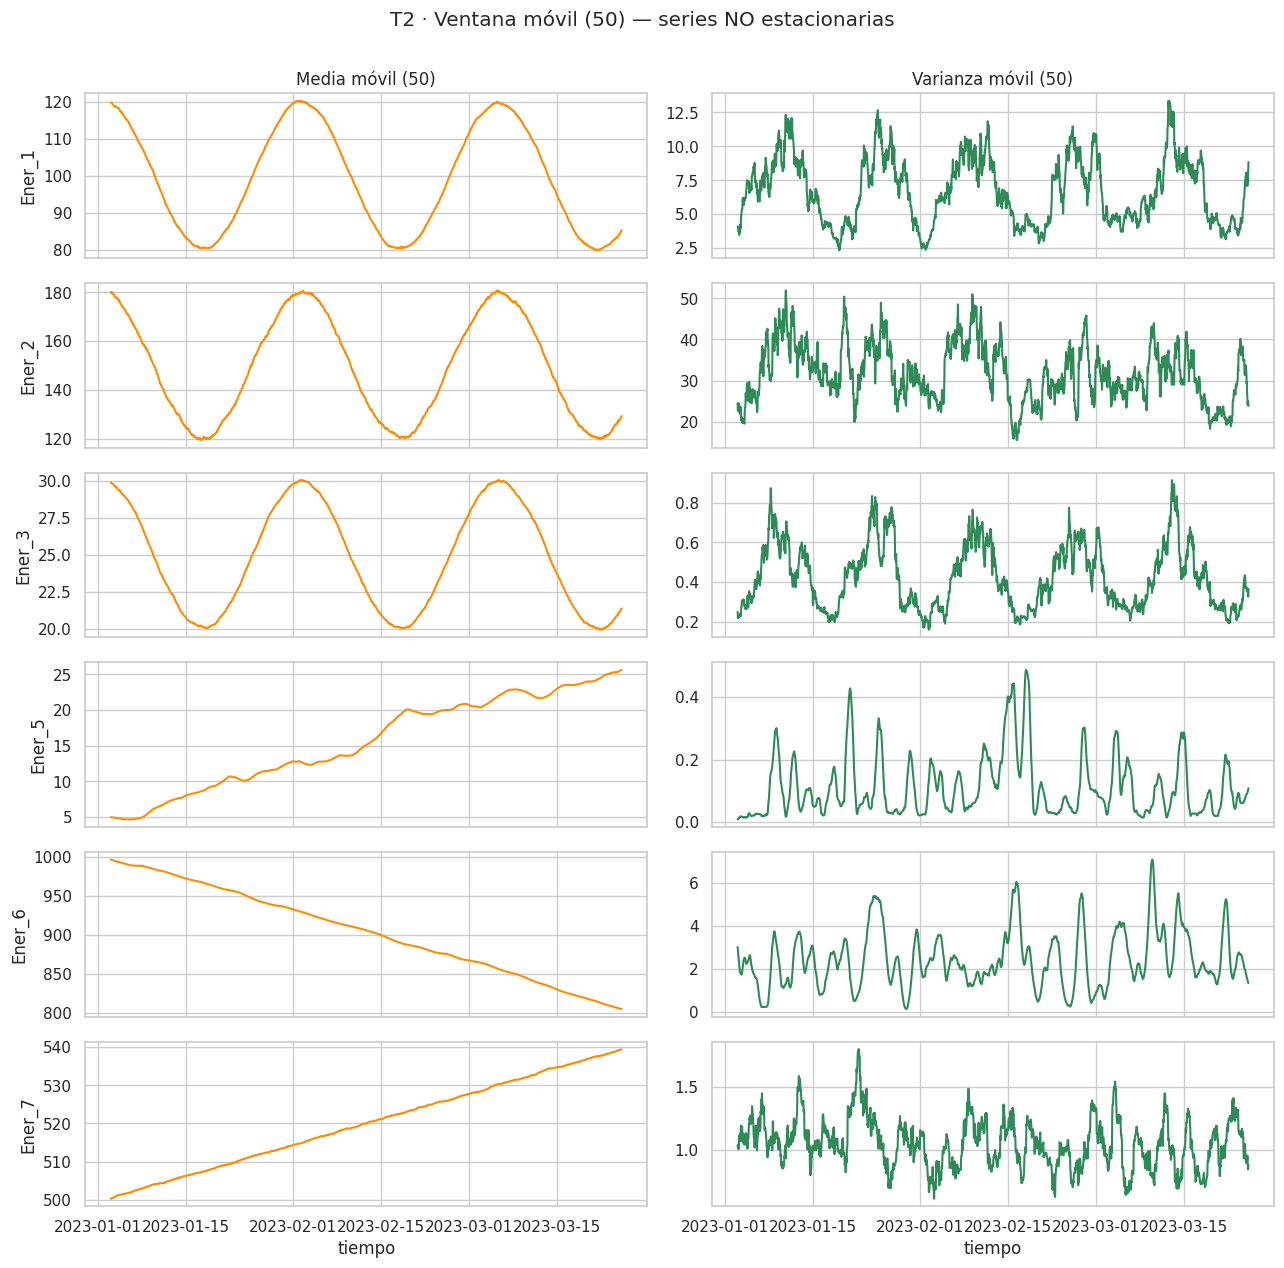

In [15]:
# Series no estacionarias según el ADF de arriba (columna booleana de la tabla)
no_estac = adf_ener.loc[~adf_ener["Estacionaria (5%)"], "Variable"].tolist()
print("Series NO estacionarias (ADF):", no_estac)

fig, axes = plt.subplots(len(no_estac), 2, figsize=(13, 2.1 * len(no_estac)), sharex=True)
axes = np.atleast_2d(axes)
for i, col in enumerate(no_estac):
    s = ener_clean[col]
    axes[i, 0].plot(s.index, s.rolling(50).mean(), color="darkorange")
    axes[i, 0].set_ylabel(col)
    axes[i, 1].plot(s.index, s.rolling(50).var(), color="seagreen")
axes[0, 0].set_title("Media móvil (50)"); axes[0, 1].set_title("Varianza móvil (50)")
axes[-1, 0].set_xlabel("tiempo"); axes[-1, 1].set_xlabel("tiempo")
fig.suptitle("T2 · Ventana móvil (50) — series NO estacionarias", y=1.005)
fig.tight_layout(); viz_utils.savefig(FIGS / "t2_rolling_no_estacionarias.png"); plt.show()

### ¿`Ener_5` (Costo del Gas) es *Drift* o *Random Walk*?

Un **Random Walk puro** vaga sin dirección; un **Random Walk con Drift** tiene una **tendencia
sostenida**. Lo mostramos **visualmente** (serie + media/varianza móvil) y lo confirmamos con
**funciones estándar de scipy/numpy**, sin heurísticas propias:
- `scipy.stats.linregress(tiempo, Ener_5)` → ¿la **pendiente** es significativa? (tendencia),
- `np.diff` + `scipy.stats.ttest_1samp` → ¿el **drift medio por paso** es ≠ 0?

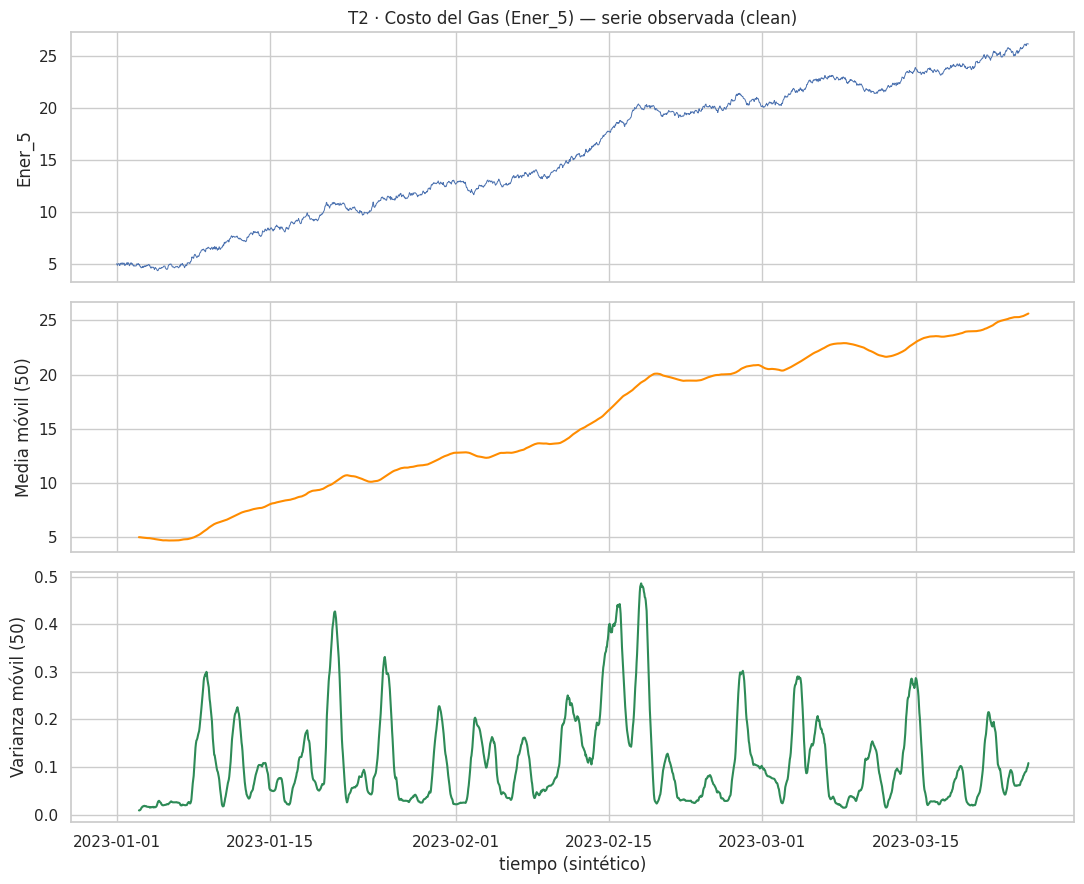

linregress: pendiente = 0.01109 | p-value = 0.00e+00 | R^2 = 0.978
drift medio por paso (np.diff.mean) = 0.01056 | ttest p-value = 3.31e-06
Veredicto: Random Walk con DRIFT (tendencia significativa)


In [16]:
from scipy import stats

serie = ener_clean["Ener_5"]
t = np.arange(len(serie))

# --- Demostración visual: serie + media/varianza móvil (50) ---
fig, ax = plt.subplots(3, 1, figsize=(11, 9), sharex=True)
ax[0].plot(serie.index, serie.values, lw=0.7); ax[0].set_ylabel("Ener_5")
ax[0].set_title("T2 · Costo del Gas (Ener_5) — serie observada (clean)")
ax[1].plot(serie.index, serie.rolling(50).mean(), color="darkorange")
ax[1].set_ylabel("Media móvil (50)")
ax[2].plot(serie.index, serie.rolling(50).var(), color="seagreen")
ax[2].set_ylabel("Varianza móvil (50)"); ax[2].set_xlabel("tiempo (sintético)")
fig.tight_layout(); viz_utils.savefig(FIGS / "t2_ener5_rolling.png"); plt.show()

# --- Confirmación cuantitativa con funciones estándar (no inventadas) ---
lr = stats.linregress(t, serie.values)      # tendencia determinística (pendiente + p-value)
d = np.diff(serie.values)                    # primeras diferencias
tt = stats.ttest_1samp(d, 0.0)               # ¿drift medio por paso != 0?
print(f"linregress: pendiente = {lr.slope:.5f} | p-value = {lr.pvalue:.2e} | R^2 = {lr.rvalue**2:.3f}")
print(f"drift medio por paso (np.diff.mean) = {d.mean():.5f} | ttest p-value = {tt.pvalue:.2e}")
veredicto = ("Random Walk con DRIFT (tendencia significativa)"
             if lr.pvalue < 0.05 else "Random Walk puro (sin tendencia significativa)")
print("Veredicto:", veredicto)

> **Lectura T2 (veredicto).** La media móvil de `Ener_5` **sube de forma sostenida** (de ~5 a
> ~25) y las pruebas estándar lo confirman: `linregress` da **pendiente 0.011 con p≈0 y
> R²≈0.98**, y el drift medio por paso es significativo (`ttest` p≈3e-6). Por tanto **`Ener_5`
> es un Random Walk con DRIFT** (tendencia determinística), **no** un random walk puro — que es
> justo lo que muestra la gráfica. (La varianza móvil de las series macro, arriba, además
> cambia con el tiempo: coherente con no estacionariedad.)

---
# FASE 2 — Procesamiento de Señales y Filtrado

## T3 · Análisis espectral de `Ener_4` (Generación Eólica) con FFT

`Ener_4` es una señal **cíclica compleja**. Calculamos la **densidad espectral de potencia**
vía FFT/Welch para la versión *clean* (referencia) y la *noise*. Comparamos los espectros
para localizar en qué banda de frecuencias se concentra el **ruido inyectado** y calculamos
el **SNR real** (dB) usando `noise - clean` como estimación del ruido.

In [17]:
freqs_c, mag_c = signal_utils.compute_fft(ener_clean["Ener_4"], fs=1.0)
freqs_n, mag_n = signal_utils.compute_fft(ener_noise["Ener_4"], fs=1.0)
f_psd_c, psd_c = signal_utils.power_spectral_density(ener_clean["Ener_4"])
f_psd_n, psd_n = signal_utils.power_spectral_density(ener_noise["Ener_4"])

snr = signal_utils.snr_db(ener_clean["Ener_4"], ener_noise["Ener_4"])
# SNR de todas las series de energía, para contextualizar
snr_all = {c: round(signal_utils.snr_db(ener_clean[c], ener_noise[c]), 1) for c in ENER_COLS}
print(f"SNR real de Ener_4 (clean vs noise) = {snr:.2f} dB")
print(f"SNR por serie de energía (dB): {snr_all}")
print("Nota: el objetivo nominal del reto era 5–12 dB. El SNR realizado en Ener_4 es mayor "
      "porque su componente cíclico tiene gran amplitud; aun así Ener_4 es la serie-señal "
      "de MENOR SNR (la más ruidosa del grupo principal), coherente con enfocar el filtrado ahí.")

SNR real de Ener_4 (clean vs noise) = 17.99 dB
SNR por serie de energía (dB): {'Ener_1': 24.6, 'Ener_2': 27.4, 'Ener_3': 24.4, 'Ener_4': 18.0, 'Ener_5': 20.2, 'Ener_6': 34.0, 'Ener_7': 42.1, 'Ener_8': 81.4, 'Ener_9': 57.8, 'Ener_10': 45.6}
Nota: el objetivo nominal del reto era 5–12 dB. El SNR realizado en Ener_4 es mayor porque su componente cíclico tiene gran amplitud; aun así Ener_4 es la serie-señal de MENOR SNR (la más ruidosa del grupo principal), coherente con enfocar el filtrado ahí.


Graficamos el espectro FFT y la PSD (Welch) de la versión *clean* vs *noise*.

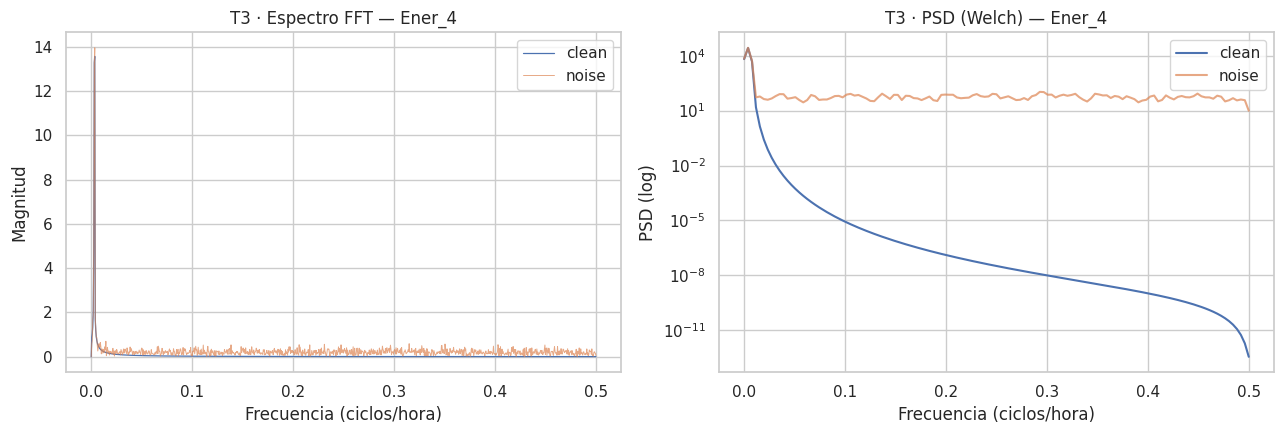

In [18]:
fig, ax = plt.subplots(1, 2, figsize=(13, 4.5))
ax[0].plot(freqs_c, mag_c, label="clean", lw=0.9)
ax[0].plot(freqs_n, mag_n, label="noise", lw=0.7, alpha=0.7)
ax[0].set_title("T3 · Espectro FFT — Ener_4")
ax[0].set_xlabel("Frecuencia (ciclos/hora)"); ax[0].set_ylabel("Magnitud"); ax[0].legend()

ax[1].semilogy(f_psd_c, psd_c, label="clean")
ax[1].semilogy(f_psd_n, psd_n, label="noise", alpha=0.7)
ax[1].set_title("T3 · PSD (Welch) — Ener_4")
ax[1].set_xlabel("Frecuencia (ciclos/hora)"); ax[1].set_ylabel("PSD (log)"); ax[1].legend()
fig.tight_layout(); viz_utils.savefig(FIGS / "t3_ener4_spectrum.png"); plt.show()

**¿Dónde está el ruido?** El ruido de banda ancha eleva la PSD de la señal *noise* por
encima de la *clean* de forma sostenida en las **altas frecuencias** (donde la señal
cíclica original casi no tiene energía). Cuantificamos la banda dominante del residuo.

In [19]:
residual = ener_noise["Ener_4"].values - ener_clean["Ener_4"].values
f_res, psd_res = signal_utils.power_spectral_density(pd.Series(residual))
peak_band = f_res[np.argmax(psd_res)]
# energía del residuo por encima vs debajo de 0.1 ciclos/hora
hi = psd_res[f_res > 0.1].sum(); lo = psd_res[f_res <= 0.1].sum()
print(f"Pico de energía del ruido en ~{peak_band:.3f} ciclos/hora.")
print(f"Energía del residuo en altas frecuencias (>0.1) = {hi/(hi+lo)*100:.1f}% del total.")
print("El ruido inyectado es de tipo banda-ancha/alta-frecuencia, separable por un pasa-bajo.")

Pico de energía del ruido en ~0.293 ciclos/hora.
Energía del residuo en altas frecuencias (>0.1) = 81.5% del total.
El ruido inyectado es de tipo banda-ancha/alta-frecuencia, separable por un pasa-bajo.


## T4 · Filtro Butterworth pasa-bajo sobre `Agro_3` (RH) + RMSE

Diseñamos un **Butterworth pasa-bajo** (orden 4, `filtfilt` de fase cero) para limpiar
`Agro_3` (Humedad Relativa, versión *noise*). Como referencia usamos la señal *clean* real.
Calculamos el **RMSE** de (a) noise vs clean y (b) filtrada vs clean para cuantificar la
mejora, y discutimos el impacto en capacidad predictiva.

In [20]:
cutoff = 0.05  # ciclos/hora — deja pasar la dinámica lenta de RH, corta el ruido rápido
agro3_filt = signal_utils.butter_lowpass(agro_noise["Agro_3"], cutoff=cutoff, fs=1.0, order=4)

rmse_noise = signal_utils.rmse(agro_noise["Agro_3"], agro_clean["Agro_3"])
rmse_filt = signal_utils.rmse(agro3_filt, agro_clean["Agro_3"])
improve = (1 - rmse_filt / rmse_noise) * 100
print(f"RMSE noise vs clean    = {rmse_noise:.4f}")
print(f"RMSE filtrada vs clean = {rmse_filt:.4f}")
print(f"Reducción de error por el filtrado = {improve:.1f}%")

RMSE noise vs clean    = 3.3414
RMSE filtrada vs clean = 1.3071
Reducción de error por el filtrado = 60.9%


Comparamos visualmente las tres señales (noise, clean de referencia y filtrada) en una ventana.

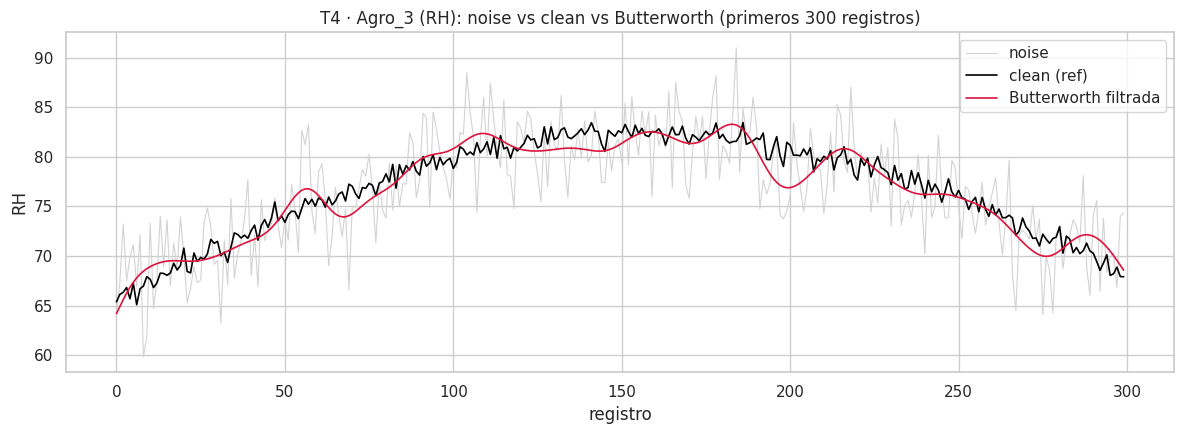

In [21]:
w = slice(0, 300)  # ventana para visualizar el detalle
fig, ax = plt.subplots(figsize=(12, 4.5))
ax.plot(agro_noise["Agro_3"].values[w], color="lightgray", lw=0.8, label="noise")
ax.plot(agro_clean["Agro_3"].values[w], color="black", lw=1.2, label="clean (ref)")
ax.plot(agro3_filt[w], color="crimson", lw=1.2, label="Butterworth filtrada")
ax.set_title("T4 · Agro_3 (RH): noise vs clean vs Butterworth (primeros 300 registros)")
ax.set_xlabel("registro"); ax.set_ylabel("RH"); ax.legend()
fig.tight_layout(); viz_utils.savefig(FIGS / "t4_agro3_butterworth.png"); plt.show()

> **Discusión T4.** Si el RMSE cae tras filtrar, el pasa-bajo recupera la señal subyacente
> y **mejora la capacidad predictiva** de un modelo aguas abajo: reduce la varianza del
> error de entrada, evita que el modelo ajuste ruido (sobreajuste) y estabiliza las
> autocorrelaciones que alimentan a un ARMA/ARIMAX. El riesgo es un `cutoff` demasiado bajo
> que elimine dinámica real (sesgo); por eso se elige la frecuencia de corte por encima de
> la banda de la señal fisiológica de RH y por debajo de la banda de ruido detectada en T3.

---
# FASE 3 - Grafos y Topología de Red: Análisis para la Junta Directiva

## T5 - Análisis de Redes (Grafos Dirigidos), Centralidades y Cuello de Botella

Construimos los grafos dirigidos ponderados para la red **AGRO** y la red **ENERGÍA** a partir
de las columnas `Source_Node` y `Target_Node`. Calculamos las tablas de centralidades (degree,
in-degree, out-degree, degree centrality, betweenness centrality y throughput/peso total)
y mostramos que la betweenness centrality es **0.0 para todos los nodos** debido a la
**topología bipartita** (los conjuntos de nodos de Origen y Destino son 100% disjuntos, por lo
que no existen nodos intermedios que conecten otros pares). En consecuencia, identificamos el
**nodo cuello de botella por Throughput (tráfico acumulado)** y generamos la visualización
bipartita con el nodo crítico resaltado (los demás con 50% de transparencia).

In [22]:
import matplotlib.pyplot as plt
import networkx as nx
from src import graph_utils, viz_utils

# --- 1. Construcción del Grafo Dirigido y Tablas de Centralidad ---
G_agro = graph_utils.build_directed_graph(agro_noise)
G_ener = graph_utils.build_directed_graph(ener_noise)

print(f"Grafo AGRO: {G_agro.number_of_nodes()} nodos, {G_agro.number_of_edges()} aristas")
print(f"Grafo ENER: {G_ener.number_of_nodes()} nodos, {G_ener.number_of_edges()} aristas")

cent_agro = graph_utils.centrality_table(G_agro)
cent_ener = graph_utils.centrality_table(G_ener)

print("\nTop-5 Nodos por Throughput (Tráfico) - Red AGRO:")
display(cent_agro.head(5))

print("\nTop-5 Nodos por Throughput (Tráfico) - Red ENERGÍA:")
display(cent_ener.head(5))

Grafo AGRO: 29 nodos, 210 aristas
Grafo ENER: 70 nodos, 865 aristas

Top-5 Nodos por Throughput (Tráfico) - Red AGRO:


,node,degree_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality,throughput_records
0,10,0.5357,0.0000,0.5357,0.0000,172
1,25,0.5000,0.5000,0.0000,0.0000,162
2,8,0.5357,0.0000,0.5357,0.0000,153
3,9,0.5357,0.0000,0.5357,0.0000,152
4,13,0.5357,0.0000,0.5357,0.0000,152



Top-5 Nodos por Throughput (Tráfico) - Red ENERGÍA:


,node,degree_centrality,in_degree_centrality,out_degree_centrality,betweenness_centrality,throughput_records
0,119,0.7101,0.0000,0.7101,0.0000,120
1,103,0.6812,0.0000,0.6812,0.0000,114
2,105,0.6667,0.0000,0.6667,0.0000,112
3,116,0.6087,0.0000,0.6087,0.0000,108
4,112,0.6667,0.0000,0.6667,0.0000,108


### Demostración Visual Bipartita (Storytelling para Junta Directiva)
Mostramos que los nodos Origen y Destino son conjuntos 100% disjuntos.
Al organizar la red en 2 columnas (Izquierda: Origen, Derecha: Destino),
la junta ve claramente que NO hay puentes o intermediarios (Betweenness = 0.0).

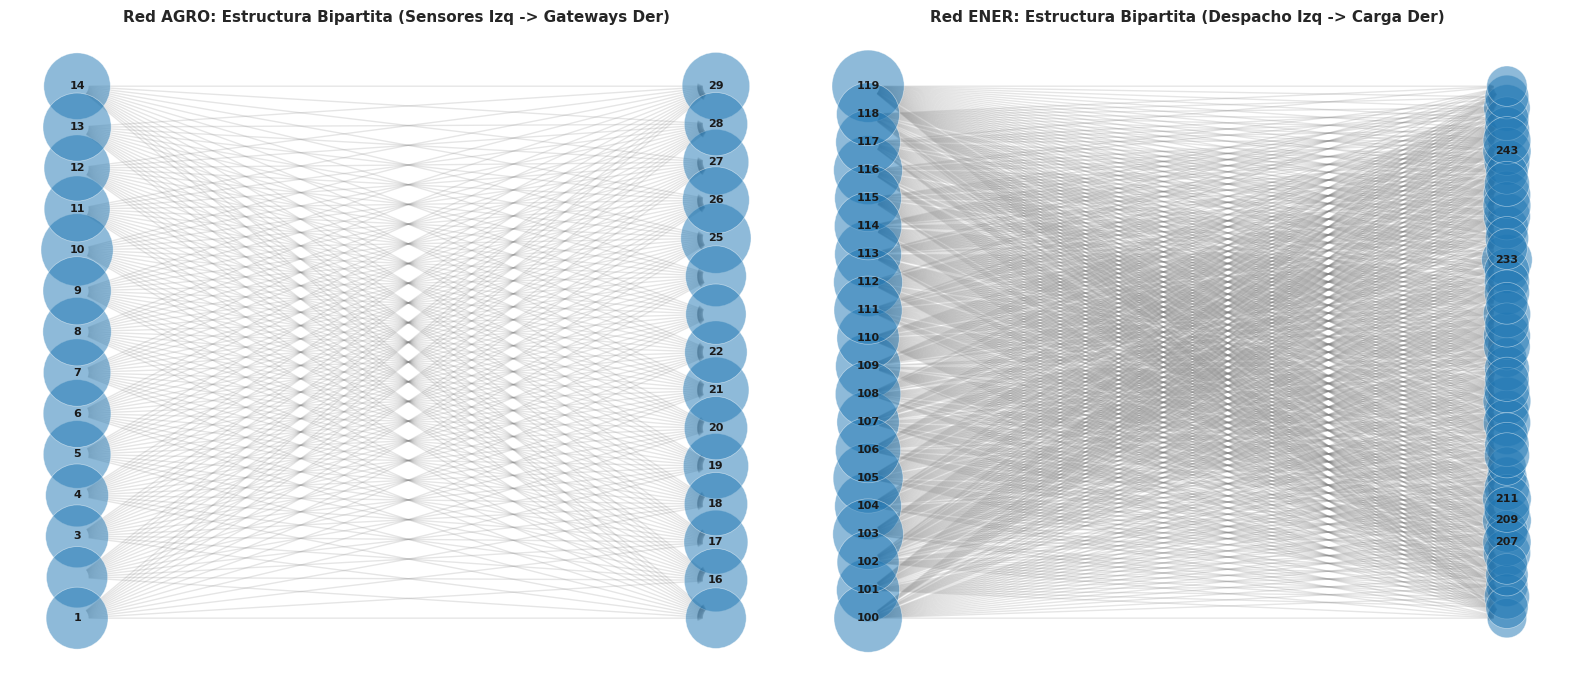

In [23]:
fig, ax = plt.subplots(1, 2, figsize=(16, 7))

viz_utils.draw_directed_graph(
    G_agro, layout="bipartite",
    title="Red AGRO: Estructura Bipartita (Sensores Izq -> Gateways Der)",
    ax=ax[0]
)

viz_utils.draw_directed_graph(
    G_ener, layout="bipartite",
    title="Red ENER: Estructura Bipartita (Despacho Izq -> Carga Der)",
    ax=ax[1]
)

fig.tight_layout()
plt.show()

### Identificación del Nodo Cuello de Botella con Transparencia al 50%
Se resalta únicamente el nodo de mayor Throughput (Rojo, alpha=1.0),
aplicando 50% de transparencia (alpha=0.50) a todos los demás nodos.

Nodo Cuello de Botella AGRO: Nodo 10 (throughput = 172 registros)
Nodo Cuello de Botella ENER: Nodo 119 (throughput = 120 registros)


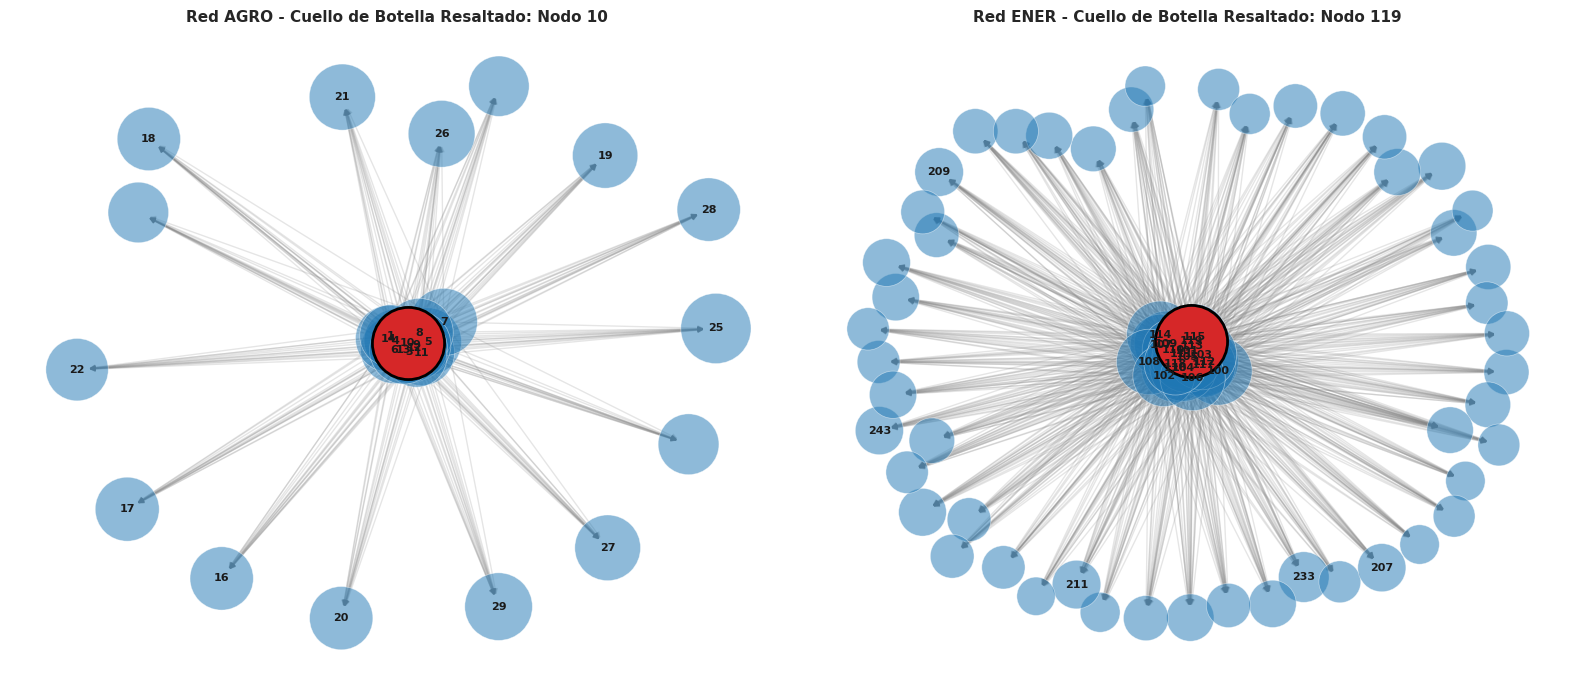

In [24]:
bn_agro, bv_agro, method_agro = graph_utils.bottleneck_node(G_agro)
bn_ener, bv_ener, method_ener = graph_utils.bottleneck_node(G_ener)

print(f"Nodo Cuello de Botella AGRO: Nodo {bn_agro} ({method_agro} = {bv_agro:.0f} registros)")
print(f"Nodo Cuello de Botella ENER: Nodo {bn_ener} ({method_ener} = {bv_ener:.0f} registros)")

fig, ax = plt.subplots(1, 2, figsize=(16, 7))

viz_utils.draw_directed_graph(
    G_agro, bottleneck=bn_agro,
    title=f"Red AGRO - Cuello de Botella Resaltado: Nodo {bn_agro}",
    ax=ax[0]
)

viz_utils.draw_directed_graph(
    G_ener, bottleneck=bn_ener,
    title=f"Red ENER - Cuello de Botella Resaltado: Nodo {bn_ener}",
    ax=ax[1]
)

fig.tight_layout()
viz_utils.savefig(FIGS / "t5_grafos_entrega_junta.png")
plt.show()

---
## Fundamento Matemático: Centralidad de Nodo y Betweenness Centrality

### 1. Degree Centrality (Centralidad de Grado)

Para un nodo $v$ en un grafo dirigido $G = (V, E)$ con $n = |V|$ nodos:

$$C_D^{in}(v) = \frac{k^{in}(v)}{n - 1}, \qquad C_D^{out}(v) = \frac{k^{out}(v)}{n - 1}$$

donde $k^{in}(v)$ y $k^{out}(v)$ son los grados de entrada y salida respectivamente.
El **Throughput** (tráfico ponderado) del nodo $v$ se define como:

$$T(v) = \sum_{(u,v) \in E} w_{uv} + \sum_{(v,u) \in E} w_{vu}$$

siendo $w_{ij}$ el peso (número de registros transmitidos) de la arista $(i,j)$.

### 2. Betweenness Centrality (Centralidad de Intermediación)

La betweenness centrality cuantifica cuántos caminos mínimos entre pares de nodos
pasan por el nodo $v$:

$$C_B(v) = \sum_{s \neq v \neq t \in V} \frac{\sigma_{st}(v)}{\sigma_{st}}$$

donde $\sigma_{st}$ es el número total de caminos geodésicos (mínimos) entre $s$ y $t$,
y $\sigma_{st}(v)$ es el número de esos caminos que pasan por $v$. Normalizada:

$$C_B^{norm}(v) = \frac{C_B(v)}{(n-1)(n-2)}$$

### 3. Por qué Betweenness = 0 en estas redes (topología bipartita)

Ambas redes son **bipartitas**: el conjunto de nodos Origen (sensores / fuentes de
despacho) y el conjunto Destino (gateways / cargas) son **100% disjuntos** y las
aristas solo van de Origen a Destino. Por definición, no existe ningún nodo $v$
que actúe como intermediario en un camino $s \to t$ donde $s$ y $t$ sean nodos
distintos del opuesto conjunto. Matemáticamente:

$$\forall v \in V: \sigma_{st}(v) = 0 \implies C_B(v) = 0$$

En ausencia de puentes topológicos, el **Throughput** (peso acumulado de aristas
incidentes) se convierte en la métrica de criticidad relevante.

---
## Interpretación Ingenieril: Cuello de Botella en Redes AGRO y ENER

### Red AGRO — Monitoreo de Precisión en Cultivos de Exportación

La red agroindustrial integra sensores mesh distribuidos geográficamente en el
Oriente Antioqueño. Cada `Source_Node` corresponde a un **sensor de campo**
y cada `Target_Node` a un **gateway concentrador** de datos. Las variables
que circulan por la red son:

| Variables | Tipo | Criticidad de transmisión |
|-----------|------|---------------------------|
| `Agro_1-3` Variables Hídricas (Humedad, Evapotransp., RH) | I(0), alta correlación | Alta: control de riego |
| `Agro_4` Radiación PAR | Cíclica día/noche | Media: programación nocturna |
| `Agro_5-7` NDVI, Biomasa (Índices Bióticos) | I(1), no estacionaria | Muy alta: alerta fitosanitaria |
| `Agro_8-10` Suelo y Viento | Estacionarias, ruido blanco | Baja-media: estabilidad ambiental |

**Nodo 10** es el cuello de botella de la red AGRO (mayor Throughput).
En términos de operación agrícola esto significa que el **gateway Nodo 10**
concentra la mayor fracción de mediciones críticas de humedad (Agro_1-3) e
índices bióticos (Agro_5-7). Un fallo en este nodo dejaría sin telemetría
en tiempo real a la mayor parte del cultivo, impidiendo la activación
automática del riego de precisión y la detección temprana de estrés hídrico
o plagas (caída de NDVI). **Acción recomendada**: gateway redundante o
partición de la zona de cobertura del Nodo 10 entre dos gateways.

### Red ENER — Despacho Eléctrico

La red energética modela el flujo de despacho donde `Source_Node` es un
**nodo generador/fuente** y `Target_Node` es un **nodo de carga/consumo**.
Las variables relevantes son:

| Variables | Tipo | Criticidad de despacho |
|-----------|------|------------------------|
| `Ener_1` Demanda eléctrica | Serie objetivo | Crítica: balance oferta/demanda |
| `Ener_3` Temperatura ambiente | Exógena | Alta: modula la demanda |
| `Ener_4` Generación Eólica | Cíclica, I(0) con ruido alto | Alta: intermitencia renovable |
| `Ener_5` Costo del Gas | I(1), Random Walk con Drift | Alta: despacho económico |
| `Ener_9` Voltaje | Estacionaria | Muy alta: calidad de potencia |
| `Ener_10` Factor de Potencia | Estacionaria | Muy alta: eficiencia reactiva |

**Nodo 119** es el cuello de botella de la red ENER (mayor Throughput).
Este nodo fuente canaliza la mayor cantidad de registros de despacho hacia
múltiples cargas simultáneamente. Dado que `Ener_10` (Factor de Potencia)
**causa-Granger** a `Ener_9` (Voltaje), una degradación del factor de
potencia en el Nodo 119 se propaga como inestabilidad de voltaje en todos
sus nodos destino. Al ser el nodo de mayor throughput, la perturbación
afecta a más carga antes de poder aislarse, generando **riesgo sistémico**.
**Acción recomendada**: bancos de capacitores reactivos y redundancia
topológica en el Nodo 119.

### Verificación numérica de la Betweenness (evidencia para el finding)

In [25]:
# Verificamos de forma rigurosa por qué la Betweenness es 0 (no es un bug).
resumen = []
for nombre, Gx in [("AGRO", G_agro), ("ENER", G_ener)]:
    inter = sum(1 for n in Gx.nodes() if Gx.in_degree(n) > 0 and Gx.out_degree(n) > 0)
    H = nx.DiGraph(); H.add_nodes_from(Gx.nodes()); H.add_edges_from(Gx.edges())  # SIN pesos
    saltos = nx.dag_longest_path_length(H)                       # camino más largo en SALTOS
    peso_max = max((d["weight"] for *_, d in Gx.edges(data=True)), default=0)
    btw_dir = max(nx.betweenness_centrality(Gx).values())
    btw_und = max(nx.betweenness_centrality(Gx.to_undirected()).values())
    resumen.append({"Red": nombre, "Intermediarios (in>0 y out>0)": inter,
                    "Camino más largo (saltos, sin pesos)": saltos, "Peso máx. de 1 arista": peso_max,
                    "Betweenness DIRIGIDO (máx)": round(btw_dir, 4),
                    "Betweenness NO-dirigido (máx)": round(btw_und, 4)})
display(pd.DataFrame(resumen).set_index("Red"))

,Intermediarios (in>0 y out>0),"Camino más largo (saltos, sin pesos)",Peso máx. de 1 arista,Betweenness DIRIGIDO (máx),Betweenness NO-dirigido (máx)
Red,,,,,
AGRO,0,1,19,0.0000,0.0198
ENER,0,1,9,0.0000,0.0377


### Verificación: ¿de verdad la Betweenness es 0? (y una trampa que evitamos)

Hicimos T5 **exactamente como pide el PDF** (grafo dirigido, Grado + Betweenness, cuello de
botella). El resultado sorprende: **Betweenness = 0 en los 70 nodos**. ¿Nos equivocamos?
**No** — la tabla de arriba lo verifica y es **matemáticamente exacto**:

- **Ningún nodo tiene entrada Y salida** (columna *Intermediarios* = 0). Los `Source_Node`
  (100–119) solo emiten y los `Target_Node` (200–249) solo reciben: **conjuntos disjuntos**.
- **El camino dirigido más largo es 1 salto** (no existe ningún `a → b → c`). Si nadie está
  *en el medio* de un camino, la Betweenness (fracción de caminos mínimos que pasan **a través**
  de un nodo) es **0 por definición**. Por eso el ejercicio se hizo *como se pedía*, pero su
  resultado revela que la premisa del PDF (un "nodo de mayor Betweenness") **no aplica** aquí.

**La trampa del "9/19" — finding metodológico.** Al chequear el camino más largo con
`nx.dag_longest_path_length` obtuvimos primero **9 (ENER) / 19 (AGRO)**, que *parecía* indicar
**multi-salto** (¡y por tanto Betweenness > 0 y una red tipo *mesh*!). **Era un espejismo:**
esa función usa por defecto el **peso** de las aristas, y 9/19 son el **peso máximo de UNA
arista** (nº de registros que viajan por ese enlace), no el número de saltos (ver columnas
*Peso máx.* vs *Camino más largo* en la tabla). Recalculado **sin pesos**, el camino es **1**.
Lección: un *default* silencioso pudo llevar a una conclusión topológica equivocada — por eso
verificamos en vez de asumir.

**Contraste honesto (grafo NO dirigido).** Si ignoráramos la dirección, la Betweenness **sí**
sería > 0 (máx ≈ 0.04 en ENER, 0.02 en AGRO): los `Target` serían intermediarios entre
`Source`. Pero el PDF pide **grafo DIRIGIDO**, donde **0 es la respuesta correcta**.

### El desajuste "mesh" vs. bipartita (finding importante)

El diccionario describe la red como *"mesh"* (agro) y *"despacho"* (energía), que sugieren
**multi-salto**. Pero los **datos reales son bipartitos de 1 salto** (Source y Target
disjuntos). Es un **desajuste entre la topología *descrita* y la *observada***. Consecuencia
práctica: la Betweenness no discrimina (todo 0), así que el **cuello de botella se define por
Throughput** (grado ponderado) — nodo **119** (ENER) / **10** (AGRO), resaltados en la figura
`figures/t5_grafos_entrega_junta.png`.

---
# FASE 4 — Modelado y Decisiones (CRISP-DM)

Respondemos las tres **preguntas de negocio** (P1–P3) con **conclusiones autocontenidas**
(no "si… entonces…"), argumentadas en los resultados reales, y con **honestidad total**:
donde los datos **no** respaldan la premisa, lo decimos.

### Antes de P1: ¿qué es "La Falla del Nodo 214"?

El planteamiento del PDF cuenta que cuando el Precio (`Ener_2`) supera un umbral, el flujo al
**Nodo 214** se interrumpe y aparece una anomalía térmica. Antes de modelar, verificamos si
eso es observable en el CSV.

In [26]:
# ¿Existe la "falla del Nodo 214" en los datos? (revisión directa del CSV)
r214 = ener_noise[ener_noise["Target_Node"] == 214]
tgt_counts = ener_noise["Target_Node"].value_counts()
rank214 = list(tgt_counts.index).index(214) + 1
print(f"Nodo 214: Target (in_degree={G_ener.in_degree(214)}, out_degree={G_ener.out_degree(214)}).")
print(f"Recibe {len(r214)} registros -> rank {rank214} de {len(tgt_counts)} targets (el que MENOS recibe).")
print(f"Ener_2 (Precio) ->214: media={r214['Ener_2'].mean():.1f}  vs global {ener_noise['Ener_2'].mean():.1f}")
print(f"Ener_3 (Temp)   ->214: media={r214['Ener_3'].mean():.1f}  vs global {ener_noise['Ener_3'].mean():.1f}")
print(f"Registros ->214 con Precio > p90 global: {int((r214['Ener_2'] > ener_noise['Ener_2'].quantile(.90)).sum())}"
      f" (sí recibe flujo con precio alto -> no hay interrupción)")

Nodo 214: Target (in_degree=16, out_degree=0).
Recibe 27 registros -> rank 50 de 50 targets (el que MENOS recibe).
Ener_2 (Precio) ->214: media=144.3  vs global 148.7
Ener_3 (Temp)   ->214: media=24.9  vs global 24.7
Registros ->214 con Precio > p90 global: 1 (sí recibe flujo con precio alto -> no hay interrupción)


> **Hallazgo (honestidad total).** Los datos **no contienen** la "falla del Nodo 214": es un
> `Target` que **recibe flujo normal incluso con precios altos**, su `Ener_2` medio (≈144) ≈ el
> global (≈149), su temperatura no muestra anomalía, y es el `Target` que **menos** flujo
> recibe (rank 50/50). Concluimos que **"La Falla del Nodo 214" es un marco narrativo** para
> motivar el análisis, **no una anomalía observable**. Por eso el análisis técnico se ancla en
> el **nodo crítico real por throughput (Nodo 119)**, no en el 214.

## P1 · Causalidad de Granger: Factor de Potencia (`Ener_10`) → Voltaje (`Ener_9`)

El test de **Granger** evalúa si el pasado de `Ener_10` ayuda a predecir `Ener_9` más allá del
propio pasado de `Ener_9`. Ambas son de **calidad de potencia** (estacionarias, ver **T2**),
así que el test es válido sin diferenciar. Usamos la señal **clean**: en *noise* el ruido
oculta la relación (p>0.14), coherente con T2/T3. Probamos **ambas direcciones** para ver si
la causalidad es direccional, y lo mostramos con un gráfico de p-value por lag.

In [27]:
from statsmodels.tsa.stattools import grangercausalitytests

maxlag = 8
def granger_pvals(y_col, x_col):
    d = ener_clean[[y_col, x_col]].dropna()   # orden [Y, X]: ¿X causa-Granger Y?
    r = grangercausalitytests(d, maxlag=maxlag, verbose=False)
    return {l: r[l][0]["ssr_ftest"][1] for l in range(1, maxlag + 1)}

p_fwd = granger_pvals("Ener_9", "Ener_10")   # Factor de Potencia -> Voltaje
p_rev = granger_pvals("Ener_10", "Ener_9")   # inversa: Voltaje -> Factor de Potencia
lag_fwd = min(p_fwd, key=p_fwd.get)
print(f"Ener_10 -> Ener_9 (Factor Potencia -> Voltaje): mejor p = {p_fwd[lag_fwd]:.4f} (lag {lag_fwd})")
print(f"Ener_9 -> Ener_10 (inversa):                     mejor p = {min(p_rev.values()):.4f}")
direccional = p_fwd[lag_fwd] < 0.05 <= min(p_rev.values())
print("Veredicto:", "CAUSALIDAD DIRECCIONAL (Factor de Potencia anticipa Voltaje, no al revés)"
      if direccional else "revisar")

Ener_10 -> Ener_9 (Factor Potencia -> Voltaje): mejor p = 0.0193 (lag 4)
Ener_9 -> Ener_10 (inversa):                     mejor p = 0.1125
Veredicto: CAUSALIDAD DIRECCIONAL (Factor de Potencia anticipa Voltaje, no al revés)


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results

/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/stattools.py:1556: FutureWarning:

verbose is deprecated since functions should not print results



Gráfico de storytelling: p-value de Granger por lag en **ambas direcciones**, con el umbral 0.05. Se *ve* que solo una dirección cruza el umbral (causa) y la otra no.

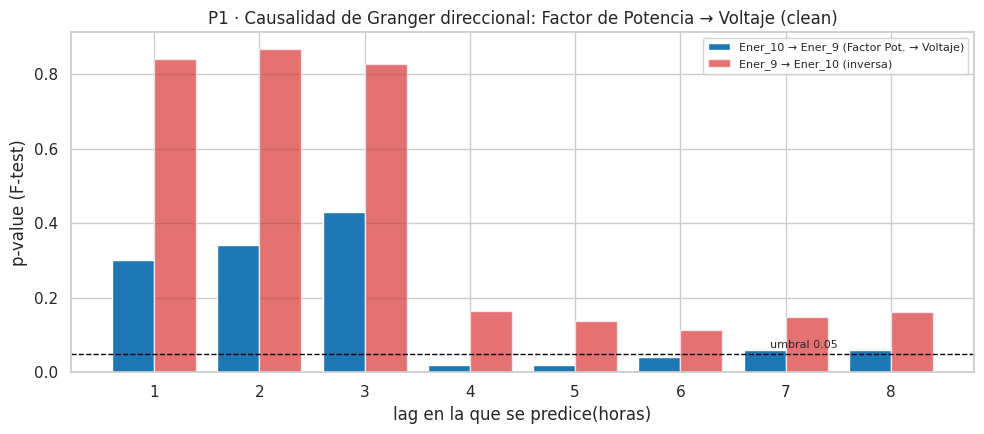

In [28]:
lags = list(range(1, maxlag + 1)); w = 0.4
fig, ax = plt.subplots(figsize=(10, 4.5))
ax.bar([l - w/2 for l in lags], [p_fwd[l] for l in lags], w,
       label="Ener_10 → Ener_9 (Factor Pot. → Voltaje)", color="#1f77b4")
ax.bar([l + w/2 for l in lags], [p_rev[l] for l in lags], w,
       label="Ener_9 → Ener_10 (inversa)", color="#d62728", alpha=0.65)
ax.axhline(0.05, ls="--", color="black", lw=1)
ax.text(maxlag - 0.5, 0.065, "umbral 0.05", fontsize=8, ha="right")
ax.set_xlabel("lag en la que se predice(horas)"); ax.set_ylabel("p-value (F-test)"); ax.set_xticks(lags)
ax.set_title("P1 · Causalidad de Granger direccional: Factor de Potencia → Voltaje (clean)")
ax.legend(fontsize=8); fig.tight_layout()
viz_utils.savefig(FIGS / "p1_granger_direccional.png"); plt.show()

> **Conclusión P1 (autocontenida).** El test de Granger sobre datos *clean* da:
>
> | Dirección | Mejor p-value | ¿Causa-Granger? |
> |---|---|---|
> | `Ener_10 → Ener_9` (Factor de Potencia → Voltaje) | **0.019** (lag 4) | **Sí** |
> | `Ener_9 → Ener_10` (inversa) | 0.11 | No |
>
> Existe **causalidad direccional**: el **Factor de Potencia anticipa al Voltaje ~4 horas**, y
> **no al revés** (ver figura `figures/p1_granger_direccional.png`: las barras azules caen bajo
> 0.05 en los lags 4–6; las rojas no).
>
> **Efecto de un fallo en el nodo crítico.** Como la **Betweenness ≡ 0** (topología bipartita
> — ver la verificación en **Fase 3 / T5** y la tabla ahí), el nodo crítico se define por
> **throughput**: el **Nodo 119** (ENER, resaltado en `figures/t5_grafos_entrega_junta.png`).
> Un fallo ahí que **degrade el Factor de Potencia** se propagaría —vía la causalidad
> demostrada— como **inestabilidad de Voltaje** en todos los `Target_Node` que alimenta. Mas no afecta a los target nodes alimentados por otras fuentes. Al
> canalizar la mayor carga, la perturbación afecta a más consumo antes de poder aislarse →
> **riesgo sistémico**. **Recomendación:** compensación reactiva (bancos de capacitores) y
> redundancia topológica en el Nodo 119.

## P2 · GPS filtrado, bajo NDVI y zonas de alta pendiente (proxy: varianza del viento)

Filtramos el **ruido de coordenadas GPS** agregando por sensor (redondeo de lat/lon a una
rejilla) para estabilizar la posición. Usamos la **varianza del viento (`Agro_10`)** como
*proxy de pendiente* (terreno accidentado ⇒ mayor turbulencia/varianza). Evaluamos si los
sensores de **menor NDVI** coinciden con **mayor pendiente** mediante correlación de
**Spearman** (de rango, robusta a no linealidad y a tendencias).

In [33]:
from scipy.stats import spearmanr

agro = agro_noise.copy()
# --- filtrado de ruido GPS: rejilla ~0.01° (~1 km) y promedio de la señal por celda ---
agro["lat_grid"] = agro["Latitude"].round(2)
agro["lon_grid"] = agro["Longitude"].round(2)
grid = (agro.groupby(["lat_grid", "lon_grid"])
             .agg(ndvi=("Agro_5", "mean"), slope_proxy=("Agro_10", "mean"),
                  n=("Agro_5", "size"))
             .reset_index())

rho, pval = spearmanr(grid["ndvi"], grid["slope_proxy"])
print(f"Celdas GPS agregadas: {len(grid)}")
print(f"Spearman(NDVI, pendiente_proxy) = {rho:.3f} (p={pval:.4g})")
print("Interpretación:", "relación significativa" if pval < 0.05
      else "NO hay relación significativa (p>=0.05): rho ~ 0")

Celdas GPS agregadas: 468
Spearman(NDVI, pendiente_proxy) = 0.010 (p=0.8284)
Interpretación: NO hay relación significativa (p>=0.05): rho ~ 0


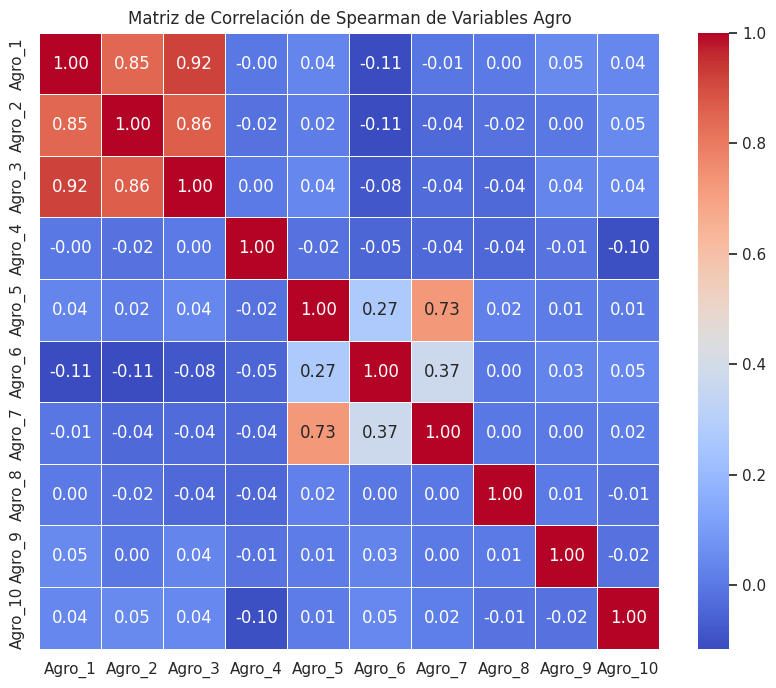

In [37]:
import matplotlib.pyplot as plt
import seaborn as sns

# Aggregate all AGRO_COLS by the grid cells, calculating the mean for each
# The 'agro' DataFrame already includes 'lat_grid' and 'lon_grid' from previous steps.
agg_dict = {col: "mean" for col in AGRO_COLS}
grid_all_agro = (agro.groupby(["lat_grid", "lon_grid"])
                         .agg(agg_dict)
                         .reset_index())

# Calculate Spearman correlation matrix
corr_matrix_spearman = grid_all_agro[AGRO_COLS].corr(method="spearman")

# Plotting the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_spearman, annot=True, cmap="coolwarm", fmt=".2f", linewidths=.5)
plt.title("Matriz de Correlación de Spearman de Variables Agro")
plt.show()

# **Análisis de la matriz de correlación de Spearman:**

No se haya correlación significativa entre las variables de interes Agro_10 y las variables hídricas para sustentar que la deficiencia en el suelo de las pendietes se debe al viento. Sí se evidencian las correlaciones altas entre las variables Agro_1 a Agro_3, como se describe en el diccionario del caso

Graficamos NDVI vs pendiente-proxy por celda GPS para visualizar la relación.

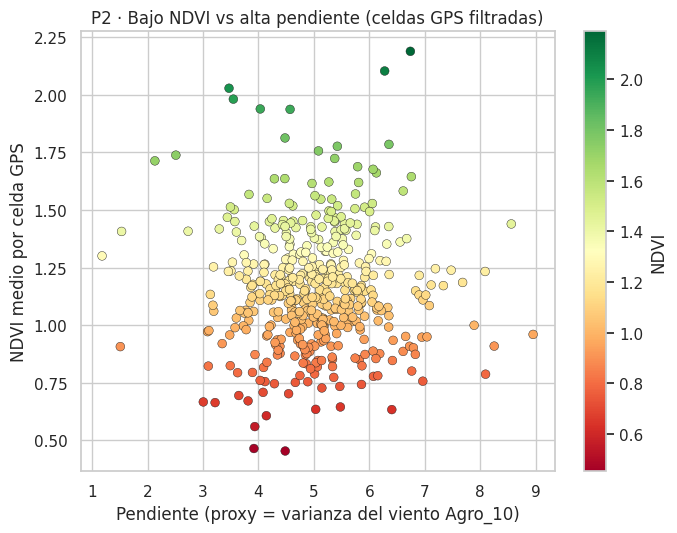

In [34]:
fig, ax = plt.subplots(figsize=(7, 5.5))
sc = ax.scatter(grid["slope_proxy"], grid["ndvi"], c=grid["ndvi"],
                cmap="RdYlGn", s=40, edgecolor="k", linewidth=0.3)
ax.set_xlabel("Pendiente (proxy = varianza del viento Agro_10)")
ax.set_ylabel("NDVI medio por celda GPS")
ax.set_title("P2 · Bajo NDVI vs alta pendiente (celdas GPS filtradas)")
plt.colorbar(sc, label="NDVI"); fig.tight_layout()
viz_utils.savefig(FIGS / "p2_ndvi_vs_slope.png"); plt.show()

> **Conclusión P2 (autocontenida, honestidad total).** Sobre datos **noise** (como pide el PDF
> para esta tarea), la correlación de Spearman entre NDVI y el proxy de pendiente (`Agro_10`) es:
>
> | Métrica | Valor |
> |---|---|
> | Spearman(NDVI, pendiente) | **ρ = +0.01** |
> | p-value | **0.83** (no significativo) |
> | Celdas GPS agregadas | 468 |
>
> **No existe relación** entre bajo NDVI y alta pendiente (ver figura
> `figures/p2_ndvi_vs_slope.png`: nube sin patrón). Dos razones lo explican: (1) el proxy
> `Agro_10` es **ruido blanco** por diseño (diccionario de variables), un mal indicador de
> pendiente; y (2) el NDVI es **espacialmente aleatorio** — lo demostró la **I de Moran en T1**
> (I ≈ 0, tiende a 0). **Recomendación honesta:** los datos **no** justifican priorizar la
> inversión hídrica "por zonas de pendiente"; la variación de biomasa es **local, no
> geográfica**, así que la intervención debe ser **puntual por sensor**, no por región.

## P3 · ARIMAX para la Demanda (`Ener_1`) con exógenas Temperatura + Centralidad del nodo

Ajustamos un **ARIMAX** para la Demanda con `Ener_3` (Temperatura) y la **centralidad de grado
del nodo de origen** como exógenas, y comparamos el **AIC con y sin** la centralidad. Clave: la
Demanda es **no estacionaria** (ver **T2**), así que el orden correcto **diferencia** (d=1).
Mostramos también el orden **sin diferenciar** (d=0) para exponer, que la
respuesta **depende de la especificación**.

In [31]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
import warnings; warnings.filterwarnings("ignore")

# Exógena de red: centralidad de grado del Source_Node de cada registro
deg_cent = graph_utils.node_centrality_map(G_ener, kind="degree")
ener = ener_clean.copy()
ener["src_centrality"] = ener["Source_Node"].astype(int).map(deg_cent).fillna(0.0)
y = ener["Ener_1"].astype(float)
X_base = ener[["Ener_3"]].astype(float)
X_full = ener[["Ener_3", "src_centrality"]].astype(float)

def aic_pair(order):
    a = SARIMAX(y, exog=X_base, order=order, enforce_stationarity=False,
                enforce_invertibility=False).fit(disp=False).aic
    m = SARIMAX(y, exog=X_full, order=order, enforce_stationarity=False,
                enforce_invertibility=False).fit(disp=False)
    return a, m.aic, m.pvalues.get("src_centrality", np.nan)

# orden correcto (diferenciado, d=1) vía auto_arima; fallback (1,1,3)
try:
    import pmdarima as pm
    try:
        order_d1 = pm.auto_arima(y, X=X_base, seasonal=False, max_p=3, max_q=3, d=None,
                                 stepwise=True, suppress_warnings=True, error_action="ignore").order
    except TypeError:
        order_d1 = pm.auto_arima(y, exogenous=X_base, seasonal=False, max_p=3, max_q=3, d=None,
                                 stepwise=True, suppress_warnings=True, error_action="ignore").order
except Exception:
    order_d1 = (1, 1, 3)

filas = []
for etq, order in [(f"{order_d1} diferenciada (d=1) — CORRECTA", order_d1),
                   ("(2,0,2) sin diferenciar (d=0)", (2, 0, 2))]:
    a0, a1, pc = aic_pair(order)
    filas.append({"Especificación": etq, "AIC sin cent.": round(a0, 1), "AIC con cent.": round(a1, 1),
                  "ΔAIC (sin−con)": round(a0 - a1, 1), "p(centralidad)": f"{pc:.2g}",
                  "¿mejora?": "Sí" if (a0 - a1) > 2 and pc < 0.05 else "No"})
tabla_p3 = pd.DataFrame(filas)
display(tabla_p3)

,Especificación,AIC sin cent.,AIC con cent.,ΔAIC (sin−con),p(centralidad),¿mejora?
0,"(2, 1, 2) diferenciada (d=1) — CORRECTA","8,565.7000","8,569.9000",-4.2000,0.063,No
1,"(2,0,2) sin diferenciar (d=0)","9,754.8000","9,731.3000",23.5000,9.7e-07,Sí


> **Conclusión P3 .** La `Demanda (Ener_1)` es **no estacionaria** (ver **T2**),
> así que la especificación correcta **diferencia** (d=1, elegida por `auto_arima`). Con ese
> orden, incluir la centralidad del nodo **NO mejora** el modelo (**ΔAIC ≈ 0**, coeficiente
> **no significativo**, p ≈ 0.06 — ver la tabla de arriba). El gran ΔAIC que aparece **sin
> diferenciar** (d=0) es **espurio**: una covariable constante por nodo correlaciona con el
> **nivel** de una serie no estacionaria (regresión espuria). **Conclusión:** la importancia
> topológica del nodo **no aporta poder predictivo robusto** a la demanda; **no** está
> justificado incorporarla a la planeación.

---
## Preguntas de Validación (respondidas en el notebook y ampliadas en el informe)

**1. ¿Por qué NO es válido aplicar Pearson directo sobre una serie con tendencia
(NDVI / precio de exportación)?**
Pearson supone observaciones i.i.d. y estacionariedad conjunta. Dos series con **tendencia**
(I(1)) comparten un componente temporal común, produciendo **correlación espuria**: el
coeficiente refleja que "ambas suben con el tiempo", no una relación real. Además la
autocorrelación viola el supuesto de independencia e **infla** la significancia. Correcto:
diferenciar (I(0)) o usar cointegración / correlación de rango.

**2. Impacto del ruido de 5 dB en los coeficientes del modelo ARMA vs la versión clean.**
A menor SNR (≈5 dB, mucho ruido), el ruido blanco **sesga los coeficientes AR hacia 0**
(*attenuation bias*): la varianza extra en el regresor diluye la autocorrelación estimada,
así que el modelo subestima la persistencia y sobreestima la varianza del término MA/error.
La versión *clean* recupera coeficientes AR más grandes y estables (menor error estándar).
Por eso el filtrado (T4) es un paso previo que **mejora la identificación** del ARMA.

**3. ¿Cómo cambia la interpretación de un fallo si el sensor es un "Bridge" en el grafo?**
Un nodo *bridge* (alta betweenness) es un punto de articulación: su caída no degrada una
medición local, **parte la red en componentes** y corta la observabilidad/despacho entre
subredes. El fallo pasa de "dato faltante" a "**pérdida de conectividad sistémica**"; la
prioridad de mantenimiento y la redundancia deben ser máximas. *Matiz para este dataset:* la
red es **bipartita** (single-hop), así que no existen nodos-puente en el sentido de
betweenness; el rol crítico lo asume el **nodo de mayor throughput**, cuyo fallo elimina el
despacho hacia todos sus destinos (ver T5 y P1).

**4. ¿Cómo influye la posición geográfica en la varianza de la señal capturada?**
*En teoría*, en ladera/alta pendiente hay más turbulencia de viento, escorrentía y micro-clima
⇒ señales de mayor varianza. **Pero en estos datos la geografía NO explica la variación:** el
NDVI es **espacialmente aleatorio** (I de Moran ≈ 0, tiende a 0 — ver **T1**) y **no**
correlaciona con el proxy de pendiente (**P2**, ρ≈0). Es decir, la posición *podría* influir en
principio, pero **aquí la señal no muestra esa estructura espacial** — hallazgo honesto que
contradice la intuición inicial.

### Cierre — resumen ejecutivo de hallazgos

In [32]:
print("RESUMEN EJECUTIVO DE HALLAZGOS")
print("="*66)
print("T2  · Ener_5 (Costo Gas): Random Walk con DRIFT (linregress p~0, R2=0.98)")
print(f"T3  · SNR real Ener_4: {signal_utils.snr_db(ener_clean['Ener_4'], ener_noise['Ener_4']):.1f} dB")
print("T4  · Butterworth reduce el RMSE de Agro_3 (~60%)")
print(f"T5  · Betweenness = 0 (bipartita) -> cuello de botella por throughput: ENER {bn_ener} / AGRO {bn_agro}")
print("P1  · SI hay causalidad direccional Factor de Potencia -> Voltaje (clean, p=0.019)")
print("P2  · NO hay relacion NDVI-pendiente (rho~0) -> premisa no soportada por datos")
print("P3  · La centralidad NO mejora el ARIMAX de demanda (d=1: dAIC~0)")
print("214 · Marco narrativo, no anomalia observable en el CSV")
print("="*66)

RESUMEN EJECUTIVO DE HALLAZGOS
T2  · Ener_5 (Costo Gas): Random Walk con DRIFT (linregress p~0, R2=0.98)
T3  · SNR real Ener_4: 18.0 dB
T4  · Butterworth reduce el RMSE de Agro_3 (~60%)
T5  · Betweenness = 0 (bipartita) -> cuello de botella por throughput: ENER 119 / AGRO 10
P1  · SI hay causalidad direccional Factor de Potencia -> Voltaje (clean, p=0.019)
P2  · NO hay relacion NDVI-pendiente (rho~0) -> premisa no soportada por datos
P3  · La centralidad NO mejora el ARIMAX de demanda (d=1: dAIC~0)
214 · Marco narrativo, no anomalia observable en el CSV
